# Portfolio Management System V3.0 - Weekly Trading Pipeline

This notebook demonstrates the complete fixed system with:
- Weekly data aggregation
- All configuration attributes properly defined
- Early stopping integration
- Comprehensive monitoring

In [1]:
# Import required libraries
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

In [2]:
# Import the system components
from portfolio_system import SystemConfig, DataPipeline
from portfolio_training_system import (
    PortfolioEnvironment, 
    PPOAgent, 
    TrainingPipeline,
    EarlyStopping
)

## 1. Configuration Setup

The fixed `SystemConfig` now includes ALL required attributes:

In [3]:
# Initialize configuration with all required attributes
config = SystemConfig()

# Set random seed for reproducibility (MUST be set before creating any components)
config.random_seed = 42  # Change this to use a different seed for different runs

# Optionally adjust for faster testing
config.max_episodes = 1000  # Reduce for testing
config.validate_every_n_episodes = 5
config.log_every_n_episodes = 5
config.save_every_n_episodes = 20

# Display key configuration parameters
print("=" * 60)
print("WEEKLY TRADING CONFIGURATION")
print("=" * 60)
print(f"\n🔒 Reproducibility: Random seed = {config.random_seed}")

print("\n📊 Data Configuration:")
print(f"  Frequency: {config.data_frequency}")
print(f"  Period: {config.data_start_date} to {config.data_end_date}")
print(f"  Tickers: {', '.join(config.tickers)}")
print(f"  Returns: {'Log' if config.use_log_returns else 'Simple'}")

print("\n🧠 Neural Network:")
print(f"  Architecture: {config.hidden_dims}")
print(f"  Activation: {config.activation}")
print(f"  Dropout: {config.dropout_rate}")
print(f"  Attention: {config.use_attention} (heads={config.attention_heads})")
print(f"  LSTM: {config.use_lstm} (layers={config.lstm_num_layers})")

print("\n🎯 Training:")
print(f"  Learning Rate: {config.learning_rate}")
print(f"  Batch Size: {config.batch_size}")
print(f"  Buffer Size: {config.buffer_size}")
print(f"  PPO Epochs: {config.n_epochs}")
print(f"  Entropy Coef: {config.entropy_coef}")

print("\n📈 Weekly Features:")
print(f"  Lookbacks: {config.feature_lookbacks} weeks")
print(f"  Reward Lookback: {config.reward_lookback} weeks")

WEEKLY TRADING CONFIGURATION

🔒 Reproducibility: Random seed = 42

📊 Data Configuration:
  Frequency: weekly
  Period: 2015-01-01 to 2025-11-13
  Tickers: NVDA, MU, AAPL, AMD, ASML, MSFT, GOOG
  Returns: Log

🧠 Neural Network:
  Architecture: [512, 256, 128]
  Activation: gelu
  Dropout: 0.3
  Attention: True (heads=8)
  LSTM: True (layers=2)

🎯 Training:
  Learning Rate: 0.0005
  Batch Size: 128
  Buffer Size: 10000
  PPO Epochs: 4
  Entropy Coef: 0.05

📈 Weekly Features:
  Lookbacks: [1, 2, 4, 8, 13, 26] weeks
  Reward Lookback: 26 weeks


## 2. Data Loading and Weekly Aggregation

In [4]:
# Initialize data pipeline
pipeline = DataPipeline(config)

print("Loading and aggregating to weekly data...")
print("=" * 60)

# Load data (will download daily and convert to weekly)
weekly_data = pipeline.load_data(use_cache=True)

print(f"\n✓ Weekly data loaded successfully!")
print(f"  Shape: {weekly_data.shape}")
print(f"  Date range: {weekly_data['date'].min().date()} to {weekly_data['date'].max().date()}")
print(f"  Weeks: {weekly_data['date'].nunique()}")
print(f"  Tickers: {', '.join(weekly_data['ticker'].unique())}")

2025-11-14 09:24:47,305 - DataPipeline - INFO - Loaded 35 selected features from data/selected_features.json
2025-11-14 09:24:47,306 - DataPipeline - INFO - Loading cached weekly data from data/weekly_market_data_cache.parquet


Loading and aggregating to weekly data...

✓ Weekly data loaded successfully!
  Shape: (3976, 13)
  Date range: 2015-01-02 to 2025-11-14
  Weeks: 568
  Tickers: NVDA, MU, AAPL, AMD, ASML, MSFT, GOOG


In [5]:
# Display weekly return statistics
print("\nWeekly Return Statistics:")
print("=" * 60)

for ticker in config.tickers:
    ticker_data = weekly_data[weekly_data['ticker'] == ticker]['log_returns'].dropna()
    if len(ticker_data) > 0:
        weekly_mean = ticker_data.mean()
        weekly_std = ticker_data.std()
        annual_return = weekly_mean * 52
        annual_vol = weekly_std * np.sqrt(52)
        sharpe = annual_return / annual_vol if annual_vol > 0 else 0
        
        print(f"\n{ticker}:")
        print(f"  Weekly mean return: {weekly_mean:.4f} ({weekly_mean*100:.2f}%)")
        print(f"  Weekly volatility:  {weekly_std:.4f} ({weekly_std*100:.2f}%)")
        print(f"  Annual return:      {annual_return:.4f} ({annual_return*100:.1f}%)")
        print(f"  Annual volatility:  {annual_vol:.4f} ({annual_vol*100:.1f}%)")
        print(f"  Sharpe ratio:       {sharpe:.2f}")


Weekly Return Statistics:

NVDA:
  Weekly mean return: 0.0105 (1.05%)
  Weekly volatility:  0.0623 (6.23%)
  Annual return:      0.5457 (54.6%)
  Annual volatility:  0.4494 (44.9%)
  Sharpe ratio:       1.21

MU:
  Weekly mean return: 0.0034 (0.34%)
  Weekly volatility:  0.0645 (6.45%)
  Annual return:      0.1777 (17.8%)
  Annual volatility:  0.4651 (46.5%)
  Sharpe ratio:       0.38

AAPL:
  Weekly mean return: 0.0041 (0.41%)
  Weekly volatility:  0.0384 (3.84%)
  Annual return:      0.2118 (21.2%)
  Annual volatility:  0.2772 (27.7%)
  Sharpe ratio:       0.76

AMD:
  Weekly mean return: 0.0079 (0.79%)
  Weekly volatility:  0.0775 (7.75%)
  Annual return:      0.4116 (41.2%)
  Annual volatility:  0.5590 (55.9%)
  Sharpe ratio:       0.74

ASML:
  Weekly mean return: 0.0040 (0.40%)
  Weekly volatility:  0.0490 (4.90%)
  Annual return:      0.2067 (20.7%)
  Annual volatility:  0.3531 (35.3%)
  Sharpe ratio:       0.59

MSFT:
  Weekly mean return: 0.0042 (0.42%)
  Weekly volatility:  

## 3. Feature Engineering

In [6]:
# Engineer features
print("Engineering weekly features...")
featured_data = pipeline.engineer_features(weekly_data)

# Get feature columns
feature_cols = [col for col in featured_data.columns 
               if col not in ['date', 'ticker', 'open', 'high', 'low', 
                             'close', 'volume', 'dividends', 'stock splits']]

print(f"\n✓ Features created: {len(feature_cols)}")
print("\nSample features (first 20):")
for i, col in enumerate(feature_cols[:20], 1):
    print(f"  {i:2d}. {col}")

# Check data quality
nan_count = featured_data[feature_cols].isna().sum().sum()
print(f"\n📊 Data Quality Check:")
print(f"  Total NaN values: {nan_count}")
print(f"  Features with NaN: {(featured_data[feature_cols].isna().sum() > 0).sum()}")

2025-11-14 09:24:47,371 - DataPipeline - INFO - Engineering features for weekly data...


Engineering weekly features...


2025-11-14 09:24:48,631 - DataPipeline - WARNING - Found NaN values in 53 feature columns
2025-11-14 09:24:48,645 - DataPipeline - WARNING - Filling 3976 remaining NaN values with 0
2025-11-14 09:24:48,650 - DataPipeline - WARNING - Found infinite values, replacing with NaN then filling...
2025-11-14 09:24:48,694 - DataPipeline - INFO - Filtered features: kept 35 selected features, removed 36 features
2025-11-14 09:24:48,694 - DataPipeline - INFO - Final feature count: 35 features



✓ Features created: 35

Sample features (first 20):
   1. high_low_ratio
   2. close_open_ratio
   3. volume_change
   4. returns_1w
   5. returns_2w
   6. volatility_2w
   7. returns_4w
   8. price_to_sma_4w
   9. volatility_4w
  10. returns_8w
  11. price_to_sma_8w
  12. volatility_8w
  13. price_to_sma_13w
  14. volatility_13w
  15. volume_ratio_13w
  16. returns_26w
  17. price_to_sma_26w
  18. volatility_26w
  19. volume_ratio_26w
  20. bb_upper

📊 Data Quality Check:
  Total NaN values: 0
  Features with NaN: 0


## 4. Create Train/Val/Test Splits

In [7]:
# Create temporal splits
print("Creating train/val/test splits...")
print("=" * 60)

splits = pipeline.create_train_val_test_splits(featured_data)

# Normalize features
print("\nNormalizing features...")
splits = pipeline.normalize_splits(splits)

# Display split information
print("\n📊 Data Splits Summary:")
for split_name, split_df in splits.items():
    if not split_df.empty:
        weeks = split_df['date'].nunique()
        rows = len(split_df)
        start = split_df['date'].min().strftime('%Y-%m-%d')
        end = split_df['date'].max().strftime('%Y-%m-%d')
        print(f"\n  {split_name.upper()}:")
        print(f"    Weeks: {weeks}")
        print(f"    Rows: {rows:,}")
        print(f"    Period: {start} to {end}")
        print(f"    Years: {(pd.to_datetime(end) - pd.to_datetime(start)).days / 365:.1f}")

2025-11-14 09:24:48,702 - DataPipeline - INFO - 
Creating train/val/test splits for weekly data...
2025-11-14 09:24:48,707 - DataPipeline - INFO -   train: 2380 rows, 2015-01-02 to 2021-07-02, 340 weeks
2025-11-14 09:24:48,707 - DataPipeline - INFO -   val: 602 rows, 2021-07-09 to 2023-02-24, 86 weeks
2025-11-14 09:24:48,708 - DataPipeline - INFO -   test: 994 rows, 2023-03-03 to 2025-11-14, 142 weeks
2025-11-14 09:24:48,762 - DataPipeline - INFO - Features normalized using RobustScaler


Creating train/val/test splits...

Normalizing features...

📊 Data Splits Summary:

  TRAIN:
    Weeks: 340
    Rows: 2,380
    Period: 2015-01-02 to 2021-07-02
    Years: 6.5

  VAL:
    Weeks: 86
    Rows: 602
    Period: 2021-07-09 to 2023-02-24
    Years: 1.6

  TEST:
    Weeks: 142
    Rows: 994
    Period: 2023-03-03 to 2025-11-14
    Years: 2.7


## 5. Initialize Environments

In [8]:
# Create environments
print("Initializing trading environments...")
print("=" * 60)

train_env = PortfolioEnvironment(splits['train'], config, mode='train')
val_env = PortfolioEnvironment(splits['val'], config, mode='val')
test_env = PortfolioEnvironment(splits['test'], config, mode='test')

print(f"\n✓ Environments created successfully!")
print(f"\n📊 Environment Details:")
print(f"  Assets: {train_env.n_assets}")
print(f"  Features per asset: {train_env.n_features}")
print(f"  Total observation dim: {train_env.observation_space.shape[0]}")
print(f"  Action space: {train_env.action_space.shape}")
print(f"\n💰 Trading Parameters:")
print(f"  Initial capital: ${config.initial_capital:,.0f}")
print(f"  Transaction costs: {config.transaction_cost_bps} bps")
print(f"  Slippage: {config.slippage_bps} bps")
print(f"  Max position: {config.max_position_size*100:.0f}%")
print(f"  Stop loss: {config.stop_loss_threshold*100:.0f}% drawdown")

INFO:PortfolioEnvironment_train:Weekly environment initialized: 7 assets, 33 features


Initializing trading environments...


INFO:PortfolioEnvironment_val:Weekly environment initialized: 7 assets, 33 features
INFO:PortfolioEnvironment_test:Weekly environment initialized: 7 assets, 33 features



✓ Environments created successfully!

📊 Environment Details:
  Assets: 7
  Features per asset: 33
  Total observation dim: 248
  Action space: (7,)

💰 Trading Parameters:
  Initial capital: $100,000
  Transaction costs: 2.5 bps
  Slippage: 1.5 bps
  Max position: 40%
  Stop loss: 40% drawdown


## 6. Initialize PPO Agent

In [9]:
# Initialize agent
print("Initializing PPO Agent...")
print("=" * 60)

state_dim = train_env.observation_space.shape[0]
action_dim = train_env.action_space.shape[0]

agent = PPOAgent(state_dim, action_dim, config)

print(f"\n✓ Agent initialized successfully!")
print(f"\n🧠 Agent Configuration:")
print(f"  State dimension: {state_dim}")
print(f"  Action dimension: {action_dim}")
print(f"  Device: {agent.device}")
print(f"  Initial exploration: {agent.exploration_rate:.3f}")

# Count parameters
actor_params = sum(p.numel() for p in agent.actor.parameters())
critic_params = sum(p.numel() for p in agent.critic.parameters())
print(f"\n📊 Model Parameters:")
print(f"  Actor network: {actor_params:,}")
print(f"  Critic network: {critic_params:,}")
print(f"  Total: {actor_params + critic_params:,}")

Initializing PPO Agent...

✓ Agent initialized successfully!

🧠 Agent Configuration:
  State dimension: 248
  Action dimension: 7
  Device: cpu
  Initial exploration: 0.400

📊 Model Parameters:
  Actor network: 862,471
  Critic network: 293,377
  Total: 1,155,848


## 9. Full Training with Early Stopping

In [10]:
# Initialize training pipeline with early stopping
print("Starting full training with early stopping...")
print("=" * 60)

training_pipeline = TrainingPipeline(config)

# Train agent
results = training_pipeline.train(
    train_env=train_env,
    val_env=val_env,
    agent=agent,
    episodes=config.max_episodes
)

print("\n" + "=" * 60)
print("TRAINING COMPLETE!")
print("=" * 60)
print(f"\n📊 Final Results:")
print(f"  Best validation Sharpe: {results['best_val_sharpe']:.3f}")
print(f"  Best episode: {results['best_episode']}")
print(f"  Final episode: {results['final_episode']}")
print(f"  Stopped early: {results['stopped_early']}")

if results['stopped_early']:
    print(f"\n⚠️ Early stopping triggered to prevent overfitting")

2025-11-14 09:24:51,216 - INFO - Random seed set to 42 for reproducibility
INFO:TrainingPipeline:Random seed set to 42 for reproducibility
2025-11-14 09:24:51,217 - INFO - Starting training...
INFO:TrainingPipeline:Starting training...
2025-11-14 09:24:51,217 - INFO - Episodes: 1000
INFO:TrainingPipeline:Episodes: 1000
2025-11-14 09:24:51,218 - INFO - Early stopping patience: 50
INFO:TrainingPipeline:Early stopping patience: 50


Starting full training with early stopping...


2025-11-14 09:24:51,452 - INFO - New best model saved: val_sharpe=-0.578
INFO:TrainingPipeline:New best model saved: val_sharpe=-0.578
2025-11-14 09:24:51,453 - INFO - Episode 0: train_reward=257.4, val_sharpe=-0.578
INFO:TrainingPipeline:Episode 0: train_reward=257.4, val_sharpe=-0.578


Episode 0: Initial val_sharpe=-0.578


2025-11-14 09:24:52,435 - INFO - New best model saved: val_sharpe=-0.534
INFO:TrainingPipeline:New best model saved: val_sharpe=-0.534
2025-11-14 09:24:52,435 - INFO - Episode 5: train_reward=218.0, val_sharpe=-0.534
INFO:TrainingPipeline:Episode 5: train_reward=218.0, val_sharpe=-0.534


...

Episode 355: val_sharpe=-0.350, patience 48/50


2025-11-14 09:25:47,158 - INFO - Episode 360: train_reward=119.1, val_sharpe=-0.348
INFO:TrainingPipeline:Episode 360: train_reward=119.1, val_sharpe=-0.348


Episode 360: val_sharpe=-0.348, patience 49/50


2025-11-14 09:25:47,916 - INFO - Early stopping at episode 365
INFO:TrainingPipeline:Early stopping at episode 365
2025-11-14 09:25:47,918 - INFO - Training completed!
INFO:TrainingPipeline:Training completed!
2025-11-14 09:25:47,918 - INFO - Best validation Sharpe: -0.239 at episode 235
INFO:TrainingPipeline:Best validation Sharpe: -0.239 at episode 235


Episode 365: val_sharpe=-0.377, patience 50/50
Early stopping triggered! Best val_sharpe=-0.244 at episode 115

TRAINING COMPLETE!

📊 Final Results:
  Best validation Sharpe: -0.239
  Best episode: 235
  Final episode: 365
  Stopped early: True

⚠️ Early stopping triggered to prevent overfitting


## 10. Plot Training History

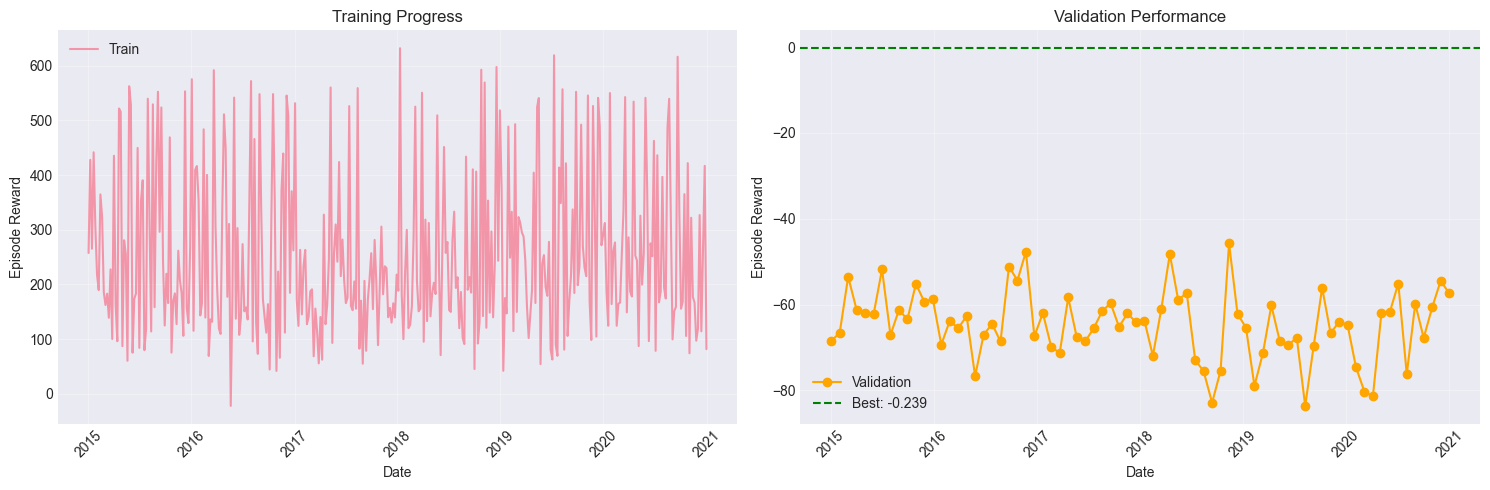

In [11]:
# Plot training history with approximate dates
if 'train_history' in results and 'val_history' in results:
    # Estimate training start date (use train split start date)
    train_dates = sorted(splits['train']['date'].unique())
    training_start_date = train_dates[0] if len(train_dates) > 0 else pd.Timestamp('2015-01-01')
    
    # Estimate episode duration (average weeks per episode)
    # Use validation split to estimate - episodes are run on train data
    avg_weeks_per_episode = len(train_dates) / max(len(results['train_history']), 1) if len(results['train_history']) > 0 else 1
    
    # Create date series for training episodes
    train_episode_dates = pd.date_range(
        start=training_start_date,
        periods=len(results['train_history']),
        freq=f'{int(avg_weeks_per_episode * 7)}D'
    )
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Training rewards with dates
    axes[0].plot(train_episode_dates, results['train_history'], alpha=0.7, label='Train')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Episode Reward')
    axes[0].set_title('Training Progress')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].tick_params(axis='x', rotation=45)
    
    # Validation performance with dates
    if results['val_history']:
        val_episode_indices = list(range(0, len(results['train_history']), config.validate_every_n_episodes))[:len(results['val_history'])]
        val_episode_dates = train_episode_dates[val_episode_indices]
        axes[1].plot(val_episode_dates, results['val_history'], 'o-', color='orange', label='Validation')
        axes[1].axhline(y=results['best_val_sharpe'], color='green', linestyle='--', label=f'Best: {results["best_val_sharpe"]:.3f}')
        axes[1].set_xlabel('Date')
        axes[1].set_ylabel('Episode Reward')
        axes[1].set_title('Validation Performance')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

## 11. Test Set Evaluation

In [12]:
# Load best model and evaluate on test set
print("Evaluating on test set...")
print("=" * 60)

# Load best model
best_model_path = config.model_dir / 'best_model.pth'
if best_model_path.exists():
    agent.load(best_model_path)
    print("✓ Best model loaded")

# Get test dates for proper time series visualization
test_dates = sorted(splits['test']['date'].unique())
test_start_date = test_dates[0] if len(test_dates) > 0 else None

# Run test episode
obs = test_env.reset()
test_returns = []
test_values = [config.initial_capital]
test_weights = []
test_dates_used = []

# Track dates during evaluation
current_step = test_env.current_step
while True:
    action, _, _ = agent.select_action(obs, training=False)
    next_obs, reward, done, truncated, info = test_env.step(action)
    
    # Get current date from environment
    if current_step < len(test_env.dates):
        test_dates_used.append(test_env.dates[current_step])
    else:
        # Fallback: use test dates if available
        if len(test_dates_used) < len(test_dates):
            test_dates_used.append(test_dates[len(test_dates_used)])
    
    test_returns.append(info['return'])
    test_values.append(info['portfolio_value'])
    test_weights.append(action.copy())
    
    obs = next_obs
    current_step += 1
    
    if done or truncated:
        break

# Ensure dates match values (add initial date)
if len(test_dates_used) == len(test_values) - 1:
    test_dates_series = pd.to_datetime([test_start_date] + test_dates_used)
else:
    # Fallback: create date series from test period
    test_dates_series = pd.to_datetime(test_dates[:len(test_values)])

# Calculate test metrics
test_returns_array = np.array(test_returns)
test_sharpe = (np.mean(test_returns_array) - config.risk_free_rate/52) / (np.std(test_returns_array) + 1e-8) * np.sqrt(52)
test_total_return = (test_values[-1] / test_values[0] - 1)
test_annual_return = (1 + test_total_return) ** (52 / len(test_returns)) - 1

# Calculate max drawdown
peak = np.maximum.accumulate(test_values)
drawdown = (np.array(test_values) - peak) / peak
max_drawdown = abs(drawdown.min())

print(f"\n📊 Test Set Performance:")
print(f"  Trading weeks: {len(test_returns)}")
print(f"  Total return: {test_total_return*100:.2f}%")
print(f"  Annual return: {test_annual_return*100:.2f}%")
print(f"  Weekly volatility: {np.std(test_returns_array)*100:.2f}%")
print(f"  Annual volatility: {np.std(test_returns_array)*np.sqrt(52)*100:.2f}%")
print(f"  Sharpe ratio: {test_sharpe:.3f}")
print(f"  Max drawdown: {max_drawdown*100:.2f}%")
print(f"  Final value: ${test_values[-1]:,.0f}")

Evaluating on test set...
✓ Best model loaded

📊 Test Set Performance:
  Trading weeks: 121
  Total return: 62.71%
  Annual return: 23.27%
  Weekly volatility: 4.35%
  Annual volatility: 31.37%
  Sharpe ratio: 0.699
  Max drawdown: 42.32%
  Final value: $162,712


## 12. Visualize Test Performance

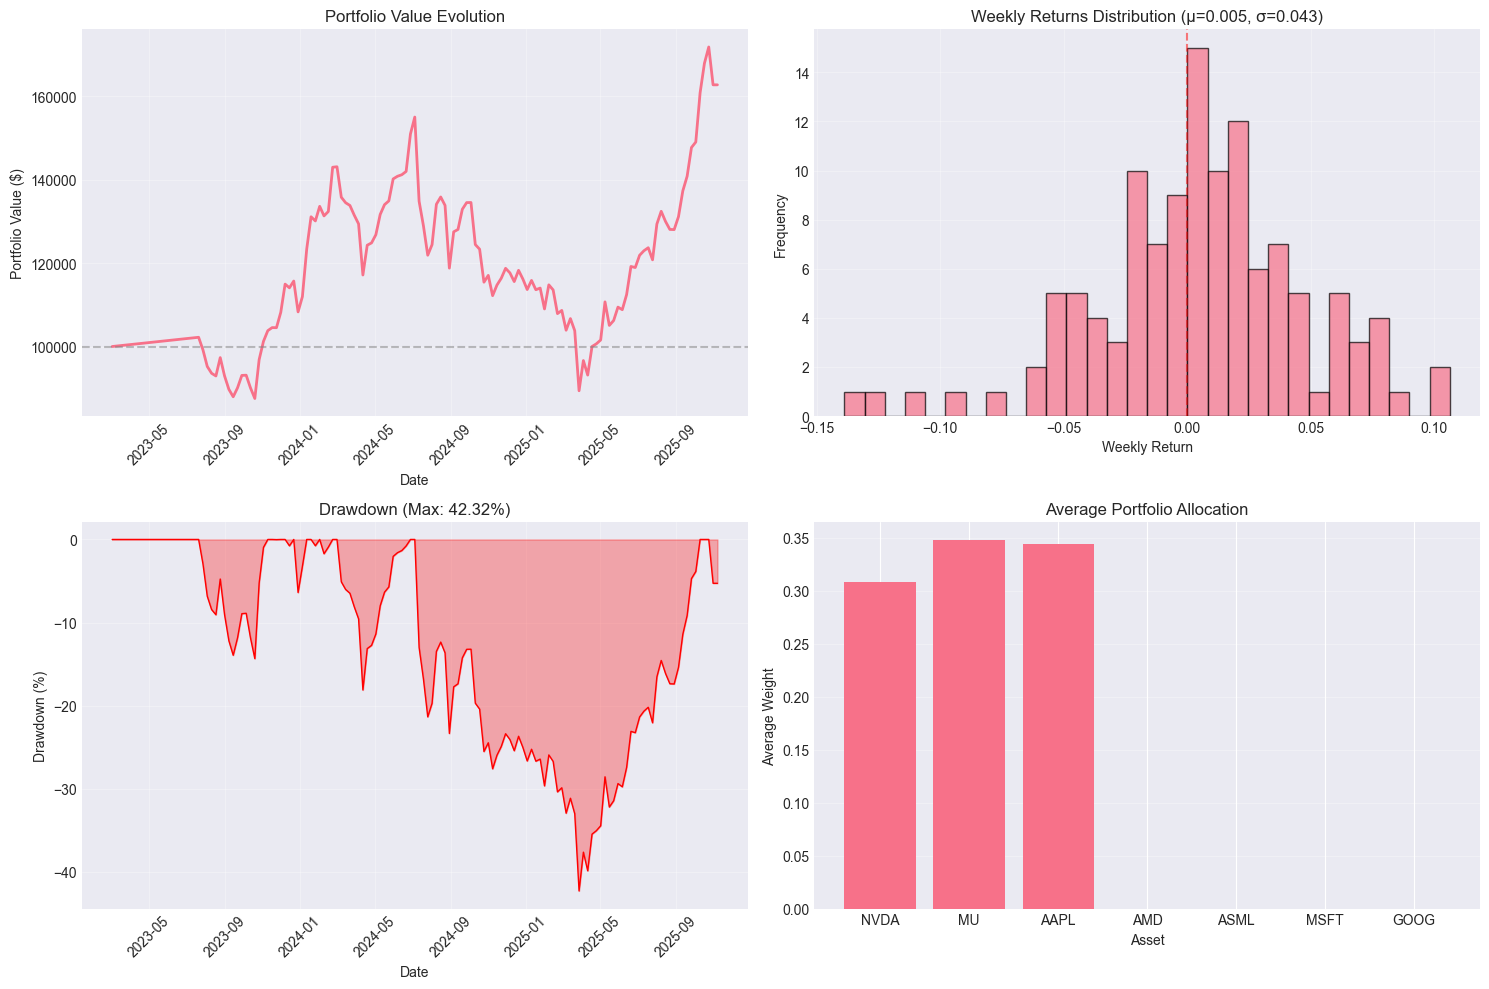

In [13]:
# Create performance visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Portfolio value over time (with dates)
axes[0, 0].plot(test_dates_series, test_values, linewidth=2)
axes[0, 0].axhline(y=config.initial_capital, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Portfolio Value ($)')
axes[0, 0].set_title('Portfolio Value Evolution')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# Weekly returns distribution
axes[0, 1].hist(test_returns_array, bins=30, alpha=0.7, edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Weekly Return')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title(f'Weekly Returns Distribution (μ={np.mean(test_returns_array):.3f}, σ={np.std(test_returns_array):.3f})')
axes[0, 1].grid(True, alpha=0.3)

# Drawdown (with dates)
axes[1, 0].fill_between(test_dates_series, 0, drawdown*100, alpha=0.3, color='red')
axes[1, 0].plot(test_dates_series, drawdown*100, color='red', linewidth=1)
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Drawdown (%)')
axes[1, 0].set_title(f'Drawdown (Max: {max_drawdown*100:.2f}%)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# Average portfolio weights
avg_weights = np.mean(test_weights, axis=0)
axes[1, 1].bar(config.tickers, avg_weights)
axes[1, 1].set_xlabel('Asset')
axes[1, 1].set_ylabel('Average Weight')
axes[1, 1].set_title('Average Portfolio Allocation')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

PORTFOLIO ALLOCATION ANALYSIS
PORTFOLIO ALLOCATION ANALYSIS

📊 Allocation Statistics:
  Number of weeks: 121
  Weight entropy: 1.0977 (max possible: 1.9459)
  Entropy ratio: 56.41%
  Weight concentration: 35.23% (max single asset)
  Weight diversity (Gini): 0.6660 (1.0 = perfect diversity)

📈 Average Portfolio Weights:
  Ticker   Mean       Std        Min        Max       
  --------------------------------------------------
  NVDA       33.13%   10.20%    9.29%   48.84%
  MU         35.23%    9.43%   10.09%   48.84%
  AAPL       31.64%   11.23%    2.33%   45.35%
  AMD         0.00%    0.00%    0.00%    0.01%
  ASML        0.00%    0.00%    0.00%    0.00%
  MSFT        0.00%    0.00%    0.00%    0.00%
  GOOG        0.00%    0.00%    0.00%    0.00%

📉 Weight Stability:
  Average weekly weight change: 0.0385

✅ Allocation looks reasonable


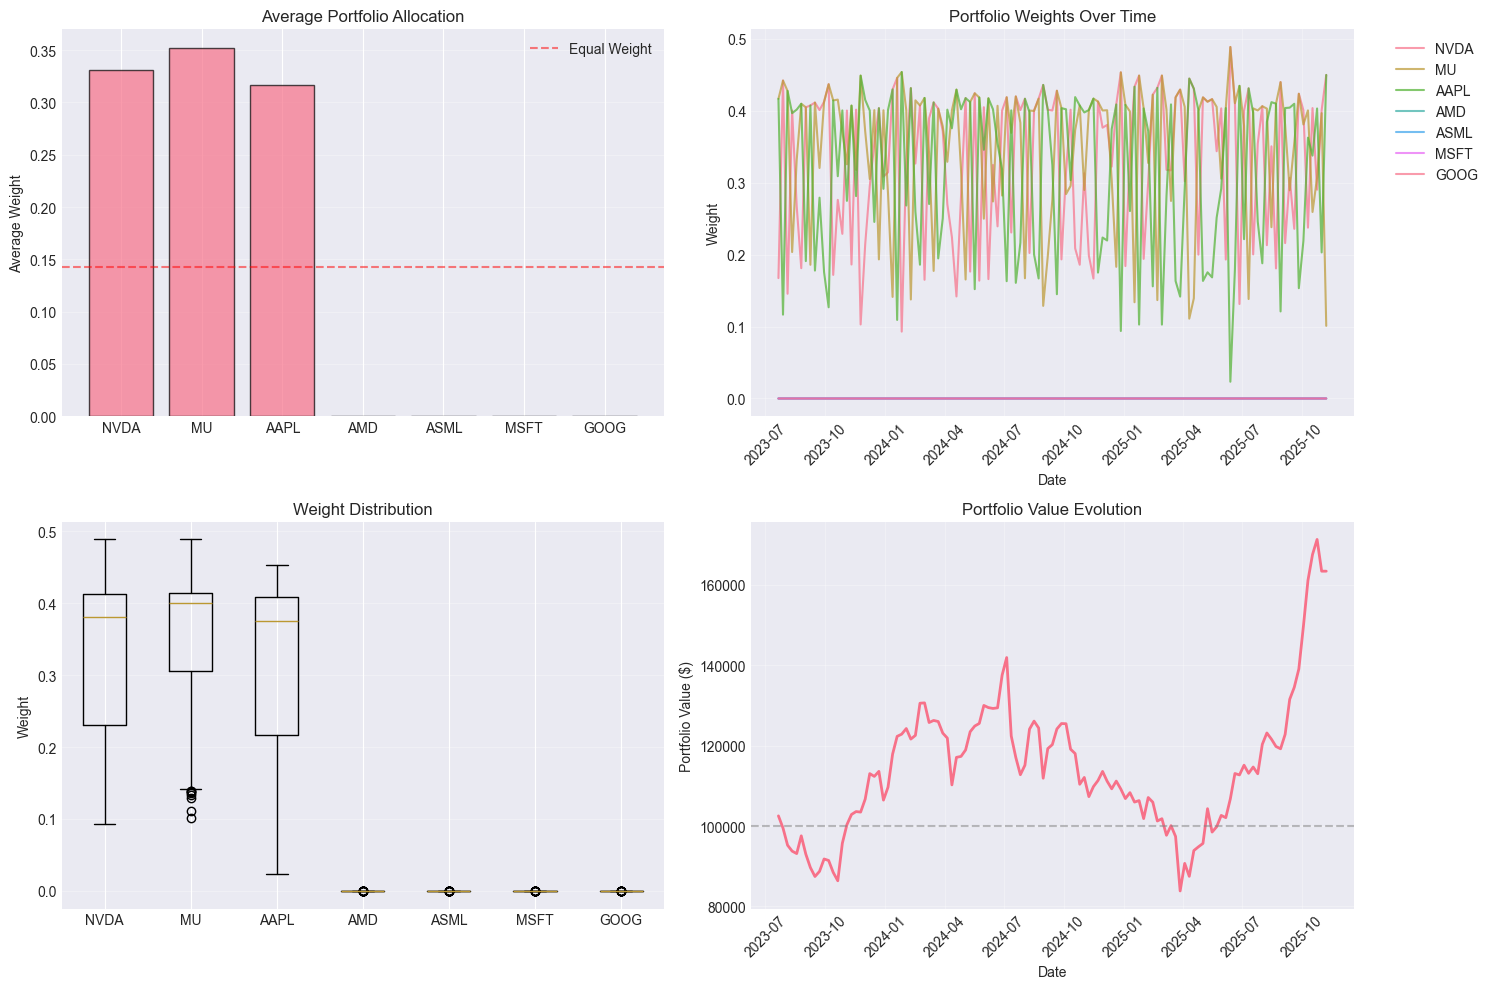


ENTROPY ANALYSIS

ENTROPY ANALYSIS

📊 Entropy Statistics:
  Total training steps: 366
  Mean entropy: 1.424856
  Std entropy: 0.194740
  Min entropy: 0.968152
  Max entropy: 1.940649
  Recent (last 10) entropy: 1.352959

✅ Entropy levels look reasonable


In [14]:
# Import analysis tools
from utile import analyze_portfolio_allocation, analyze_entropy

# Analyze portfolio allocation strategy
print("=" * 70)
print("PORTFOLIO ALLOCATION ANALYSIS")
print("=" * 70)
allocation_results = analyze_portfolio_allocation(
    agent=agent,
    test_env=test_env,
    config=config,
    plot=True
)

# Analyze entropy during training
print("\n" + "=" * 70)
print("ENTROPY ANALYSIS")
print("=" * 70)
entropy_results = analyze_entropy(agent)


## 13. Compare with Buy & Hold Benchmark

COMPARING RL AGENT WITH BENCHMARKS

📊 Performance Comparison:

                    RL Agent    Buy & Hold      QQQ        vs B&H    vs QQQ
  Annual Return:      23.27%      56.96%      32.47%     -33.69%      -9.20%
  Sharpe Ratio:       0.699       1.500       1.372      -0.800      -0.673
  Max Drawdown:       42.32%      33.35%      21.34%      +8.97%     +20.98%
  Total Return:       62.71%     239.54%     114.37%    -176.82%     -51.66%


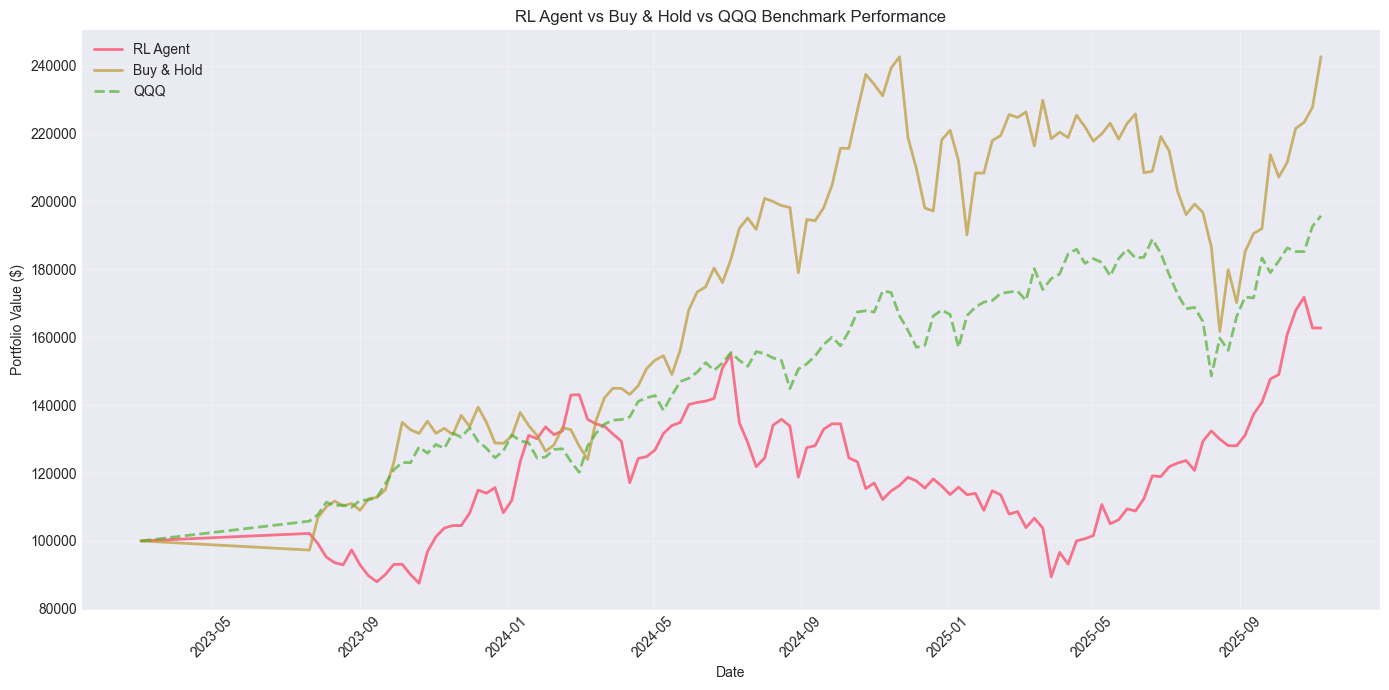

In [15]:
# Import benchmark calculations from portfolio_system
from portfolio_system import calculate_buy_hold_performance, calculate_qqq_performance

# Calculate benchmark performances
print("=" * 70)
print("COMPARING RL AGENT WITH BENCHMARKS")
print("=" * 70)

bh_results = calculate_buy_hold_performance(splits['test'], config)
qqq_results = calculate_qqq_performance(splits['test'], config)

# Extract metrics from buy-and-hold
bh_annual_return = bh_results['annual_return']
bh_sharpe = bh_results['sharpe']
bh_max_drawdown = bh_results['max_drawdown']
bh_total_return = bh_results['total_return']
bh_values = bh_results['portfolio_values']

# Extract metrics from QQQ
qqq_annual_return = qqq_results['annual_return']
qqq_sharpe = qqq_results['sharpe']
qqq_max_drawdown = qqq_results['max_drawdown']
qqq_total_return = qqq_results['total_return']
qqq_values = qqq_results['portfolio_values']

print("\n📊 Performance Comparison:")
print("\n                    RL Agent    Buy & Hold      QQQ        vs B&H    vs QQQ")
print("  " + "="*75)
print(f"  Annual Return:    {test_annual_return*100:7.2f}%    {bh_annual_return*100:7.2f}%    {qqq_annual_return*100:7.2f}%    {(test_annual_return-bh_annual_return)*100:+7.2f}%    {(test_annual_return-qqq_annual_return)*100:+7.2f}%")
print(f"  Sharpe Ratio:     {test_sharpe:7.3f}     {bh_sharpe:7.3f}     {qqq_sharpe:7.3f}     {test_sharpe-bh_sharpe:+7.3f}     {test_sharpe-qqq_sharpe:+7.3f}")
print(f"  Max Drawdown:     {max_drawdown*100:7.2f}%    {bh_max_drawdown*100:7.2f}%    {qqq_max_drawdown*100:7.2f}%    {(max_drawdown-bh_max_drawdown)*100:+7.2f}%    {(max_drawdown-qqq_max_drawdown)*100:+7.2f}%")
print(f"  Total Return:     {test_total_return*100:7.2f}%    {bh_total_return*100:7.2f}%    {qqq_total_return*100:7.2f}%    {(test_total_return-bh_total_return)*100:+7.2f}%    {(test_total_return-qqq_total_return)*100:+7.2f}%")

# Ensure all use same dates - get dates from test data
test_data_dates = sorted(splits['test']['date'].unique())
if len(test_dates_series) == len(test_values):
    comparison_dates = test_dates_series
elif len(test_data_dates) >= len(test_values):
    comparison_dates = pd.to_datetime(test_data_dates[:len(test_values)])
else:
    comparison_dates = pd.date_range(start=test_start_date, periods=len(test_values), freq='W-FRI')

# Align all values to same length
min_len = min(len(test_values), len(bh_values), len(qqq_values))
test_values_aligned = test_values[:min_len]
bh_values_aligned = bh_values[:min_len]
qqq_values_aligned = qqq_values[:min_len]
comparison_dates_aligned = comparison_dates[:min_len]

# Plot comparison with dates
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(comparison_dates_aligned, test_values_aligned, label='RL Agent', linewidth=2)
ax.plot(comparison_dates_aligned, bh_values_aligned, label='Buy & Hold', linewidth=2, alpha=0.7)
ax.plot(comparison_dates_aligned, qqq_values_aligned, label='QQQ', linewidth=2, alpha=0.7, linestyle='--')
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value ($)')
ax.set_title('RL Agent vs Buy & Hold vs QQQ Benchmark Performance')
ax.legend()
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 14. Summary and Diagnostics

In [16]:
print("\n" + "=" * 60)
print("SYSTEM DIAGNOSTICS")
print("=" * 60)

# Check for common issues
issues = []

# 1. Check for overfitting
if results['best_val_sharpe'] > 0 and test_sharpe < results['best_val_sharpe'] * 0.5:
    issues.append("⚠️ Significant degradation from validation to test (possible overfitting)")

# 2. Check for policy collapse
weight_std = np.std(avg_weights)
if weight_std < 0.05:
    issues.append("⚠️ Low weight diversity (possible policy collapse)")

# 3. Check exploration
if agent.exploration_rate < 0.01:
    issues.append("⚠️ Very low exploration rate")

# 4. Check entropy
if agent.entropies and np.mean(agent.entropies[-10:]) < 0.01:
    issues.append("⚠️ Low entropy in recent training")

# 5. Check performance
if test_sharpe < 0:
    issues.append("⚠️ Negative Sharpe ratio on test set")

if issues:
    print("\n🚨 Potential Issues Detected:")
    for issue in issues:
        print(f"  {issue}")
else:
    print("\n✅ No major issues detected!")

print("\n📈 Key Success Metrics:")
print(f"  ✓ Test Sharpe > 0.5: {'Yes' if test_sharpe > 0.5 else 'No'}")
print(f"  ✓ Outperforms B&H: {'Yes' if test_sharpe > bh_sharpe else 'No'}")
print(f"  ✓ Max DD < 30%: {'Yes' if max_drawdown < 0.3 else 'No'}")
print(f"  ✓ Positive return: {'Yes' if test_total_return > 0 else 'No'}")

print("\n" + "=" * 60)
print("WEEKLY TRADING SYSTEM EVALUATION COMPLETE!")
print("=" * 60)


SYSTEM DIAGNOSTICS

✅ No major issues detected!

📈 Key Success Metrics:
  ✓ Test Sharpe > 0.5: Yes
  ✓ Outperforms B&H: No
  ✓ Max DD < 30%: No
  ✓ Positive return: Yes

WEEKLY TRADING SYSTEM EVALUATION COMPLETE!
